# 📈 Introduction to Time Series

| Item          | Name                   |   |   |   |
|---------------|------------------------|---|---|---|
| Professor     | Davy WAI               |   |   |   |
| School        | Le Wagon               |   |   |   |
| Program       | Data Science           |   |   |   |
| City, Country | Amsterdam, Netherlands |   |   |   |
| Batch         | 2079                   |   |   |   |
| Date         | Thursday, August 5th, 2025                   |   |   |   |

## 📚 Libraries

In [1]:
# DATA MANIPULATION
import pandas as pd
import numpy as np

# DATA VIZ
import seaborn as sns
import matplotlib.pyplot as plt

# EVALUATION METRICS
from sklearn.metrics import r2_score

# DECOMPOSING TS
from statsmodels.tsa.seasonal import seasonal_decompose

# STATIONARITY
from statsmodels.tsa.stattools import adfuller

## 💾 Load dataset

In [2]:
url = "https://wagon-public-datasets.s3.amazonaws.com/05-Machine-Learning/09-Time-Series/new_drugs.csv"

In [3]:
df = pd.read_csv(url)
df

,date,value
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869
...,...,...
199,2008-02-01,21.654285
200,2008-03-01,18.264945
201,2008-04-01,23.107677
202,2008-05-01,22.912510


In [4]:
df.dtypes

date      object
value    float64
dtype: object

## ⏰ Basic Preprocessing

In [5]:
df.columns

Index(['date', 'value'], dtype='object')

In [6]:
df["date"] = pd.to_datetime(df["date"])

In [7]:
df.dtypes

date     datetime64[ns]
value           float64
dtype: object

In [8]:
# df = df.set_index("date")
df.set_index("date", inplace = True)

In [9]:
df

,value
date,
1991-07-01,3.526591
1991-08-01,3.180891
1991-09-01,3.252221
1991-10-01,3.611003
1991-11-01,3.565869
...,...
2008-02-01,21.654285
2008-03-01,18.264945
2008-04-01,23.107677


## 💹 Plotting the Time Series

<Axes: xlabel='date'>

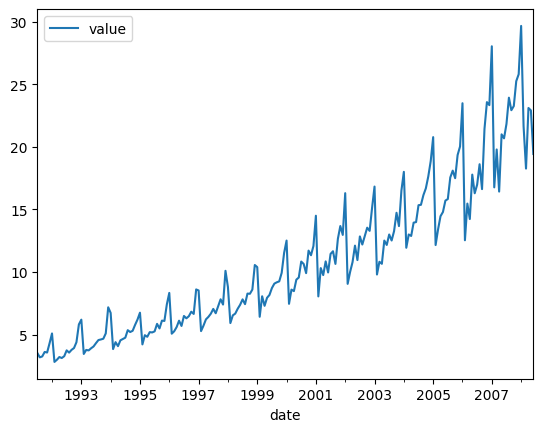

In [10]:
df.plot()

## 🧑🏻‍🔬 Decomposing the original Time Series

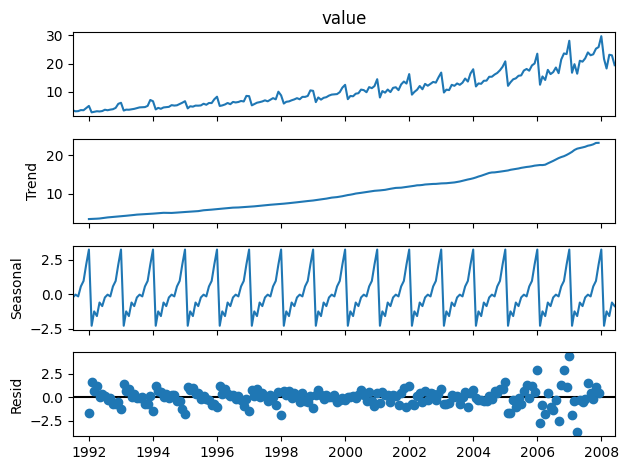

In [11]:
# Additive Decomposition (y = Trend + Seasonal + Residuals)
result_add = seasonal_decompose(df["value"], model='additive')
result_add.plot();

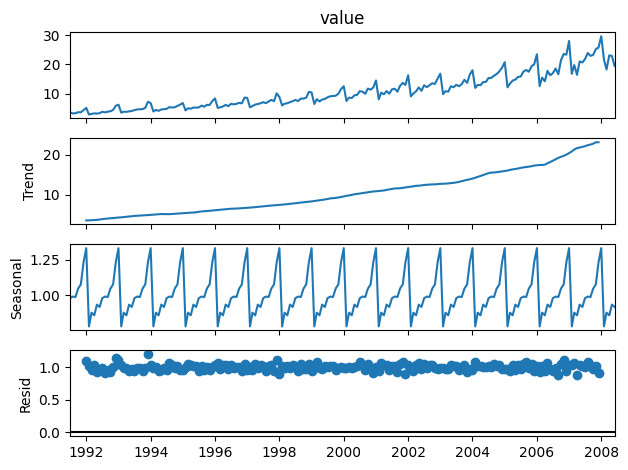

In [12]:
# Multiplicative Decomposition (y = Trend * Seasonal * Residuals)
result_mult = seasonal_decompose(df["value"], model='multiplicative')
result_mult.plot();

## 🔄 Removing seasonality

In [13]:
df["deseasonalized"] = df["value"]/result_mult.seasonal

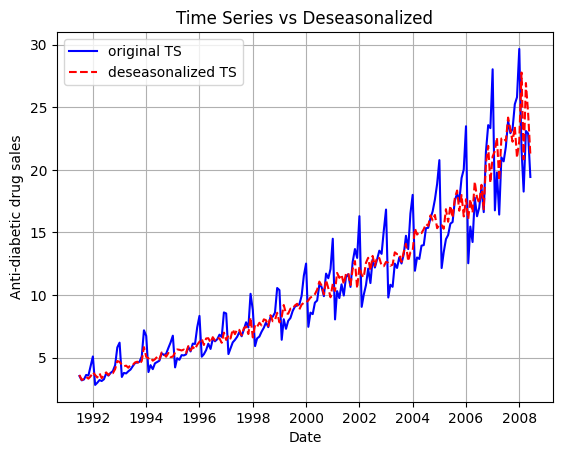

In [14]:
# PLOTS
plt.plot(df["value"],label="original TS", c="b");
plt.plot(df["deseasonalized"],label="deseasonalized TS", c="r", linestyle='dashed');
# CUSTOMIZATION
plt.xlabel("Date")
plt.ylabel("Anti-diabetic drug sales")
plt.title("Time Series vs Deseasonalized")
plt.grid()
plt.legend(loc="best")
# SHOW
plt.show()


##  📈 Linearize the TS

In [15]:
df["log"] = np.log(df["deseasonalized"])

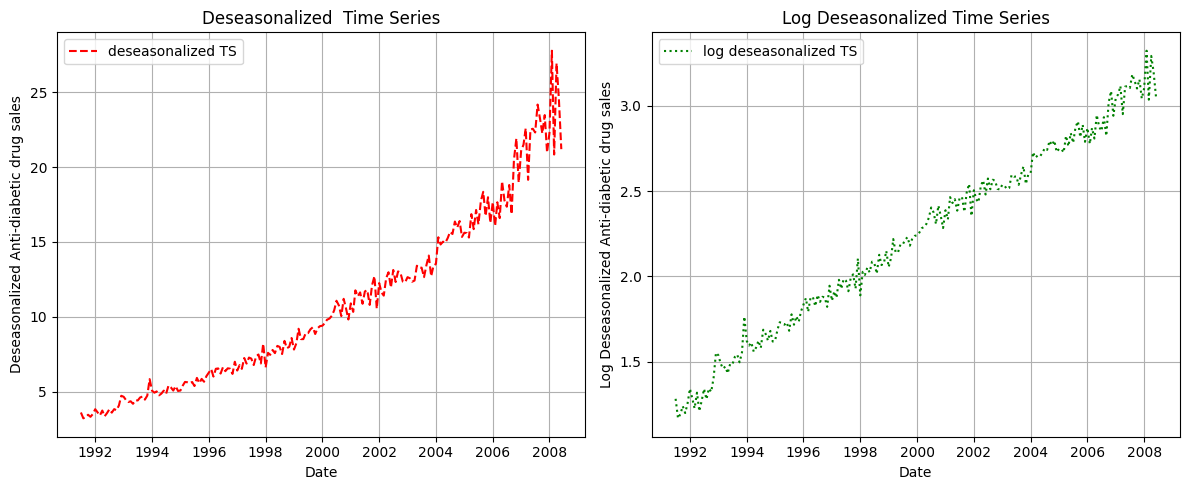

In [39]:
import matplotlib.pyplot as plt

# Create two subplots side by side
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))  # adjust figsize as needed

# First subplot: original time series
axs[0].plot(df["deseasonalized"], label="deseasonalized TS", c="r", linestyle='dashed')
axs[0].set_xlabel("Date")
axs[0].set_ylabel("Deseasonalized Anti-diabetic drug sales")
axs[0].set_title("Deseasonalized  Time Series")
axs[0].grid()
axs[0].legend(loc="best")

# Second subplot: deseasonalized time series
axs[1].plot(df["log"], label="log deseasonalized TS", c="g", linestyle='dotted')
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Log Deseasonalized Anti-diabetic drug sales")
axs[1].set_title("Log Deseasonalized Time Series")
axs[1].grid()
axs[1].legend(loc="best")

# Layout adjustment
plt.tight_layout()
plt.show()


## ✂️ Temporal Train Test Split

In [40]:
train_ratio = 0.60

In [41]:
len(df)

204

In [42]:
last_train_index = round(len(df)*train_ratio)
last_train_index

122

In [43]:
df_train = df[:last_train_index]
df_train.tail()

,value,deseasonalized,log
date,,,
2001-04-01,9.753358,11.370500,2.431022
2001-05-01,10.850382,11.628983,2.453501
2001-06-01,9.961719,10.868121,2.385834
2001-07-01,11.443601,11.694943,2.459157
2001-08-01,11.659239,11.780313,2.466430


In [44]:
df_test = df[last_train_index:]
df_test.head()

,value,deseasonalized,log
date,,,
2001-09-01,10.647060,10.793655,2.378958
2001-10-01,12.652134,12.101417,2.493323
2001-11-01,13.674466,12.713652,2.542676
2001-12-01,12.965735,10.538114,2.354999
2002-01-01,16.300269,12.250809,2.505592


In [45]:
len(df_train)

122

In [46]:
len(df_test)

82

## 🐣 Baseline Model = copy-paste the previous value!

In [49]:
comparisons_with_baseline = pd.concat([df_test["value"], df_test["value"].shift(1).dropna()], axis="columns")
comparisons_with_baseline.columns = ["real values", "shifted values"]
comparisons_with_baseline

,real values,shifted values
date,,
2001-09-01,10.647060,NaN
2001-10-01,12.652134,10.647060
2001-11-01,13.674466,12.652134
2001-12-01,12.965735,13.674466
2002-01-01,16.300269,12.965735
...,...,...
2008-02-01,21.654285,29.665356
2008-03-01,18.264945,21.654285
2008-04-01,23.107677,18.264945


In [50]:
y_pred_baseline = df_test["value"].shift(1).dropna()
y_pred_baseline

date
2001-10-01    10.647060
2001-11-01    12.652134
2001-12-01    13.674466
2002-01-01    12.965735
2002-02-01    16.300269
                ...    
2008-02-01    29.665356
2008-03-01    21.654285
2008-04-01    18.264945
2008-05-01    23.107677
2008-06-01    22.912510
Name: value, Length: 81, dtype: float64

In [51]:
r2_score(df_test["value"][1:], y_pred_baseline)

0.5069517261286796

## 🧑🏻‍🔬 Decomposing the deseasonalized and delinearized Time Series

In [52]:
df.tail()

,value,deseasonalized,log
date,,,
2008-02-01,21.654285,27.777795,3.324237
2008-03-01,18.264945,20.841377,3.036940
2008-04-01,23.107677,26.939013,3.293576
2008-05-01,22.912510,24.556665,3.200983
2008-06-01,19.431740,21.199804,3.053992


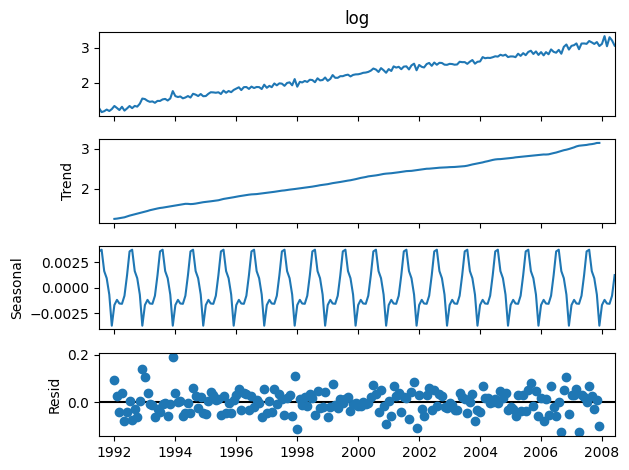

In [53]:
# Additive Decomposition (y = Trend + Seasonal + Residuals)
result_add_log = seasonal_decompose(df["log"], model='additive')
result_add_log.plot();


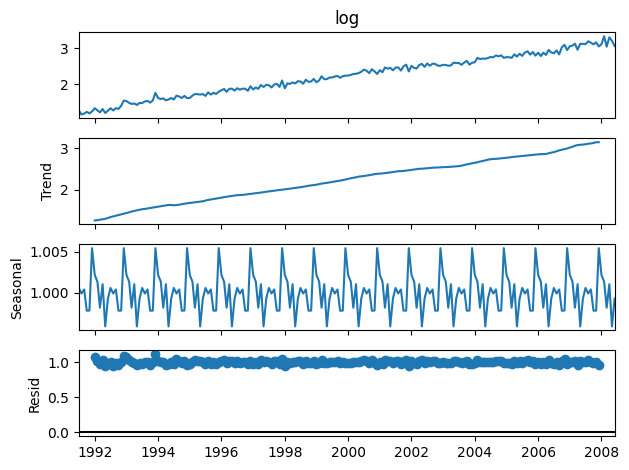

In [54]:
# Multiplicative Decomposition (y = Trend * Seasonal * Residuals)
result_mult_log = seasonal_decompose(df["log"], model='multiplicative')
result_mult_log.plot();

## 📏 Stationarity - tested with the ADF

In [55]:
adfuller(df["value"])

(3.1451856893067514,
 1.0,
 15,
 188,
 {'1%': -3.465620397124192,
  '5%': -2.8770397560752436,
  '10%': -2.5750324547306476},
 549.6705685364172)

ℹ️ The p-value is located at the second position of the tuple when running the adfuller test :) 

In [56]:
p_value = adfuller(df["value"])[1]
p_value

1.0

In [57]:
p_value < 0.05

False

😭 No stationarity for the original Time Series at the moment...

In [58]:
residuals_add = result_add.resid.dropna()
adfuller(residuals_add)[1]

0.0002852221054737728

In [59]:
residuals_mul = result_mult.resid.dropna()
adfuller(residuals_mul)[1]

1.7472595795336473e-07

💪 The residuals are very stationary both for the multiplicative and additive residuals of the original Time Series.

⚠️ We said we wanted to work on the deseasonalized and linearized TS! So let's investigate the stationarity of the latter!

In [60]:
df["log"]

date
1991-07-01    1.282057
1991-08-01    1.167492
1991-09-01    1.193013
1991-10-01    1.239482
1991-11-01    1.198554
                ...   
2008-02-01    3.324237
2008-03-01    3.036940
2008-04-01    3.293576
2008-05-01    3.200983
2008-06-01    3.053992
Name: log, Length: 204, dtype: float64

In [61]:
residuals_add_log = result_add_log.resid.dropna()
adfuller(residuals_add_log)[1]

1.1404085374389765e-08

In [37]:
residuals_mult_log = result_mult_log.resid.dropna()
adfuller(residuals_mult_log)[1]

1.0150468870830262e-08

## 🤖 Time Series Modeling / Forecasting

### 📆 AR model (choosing "p" values from the past)

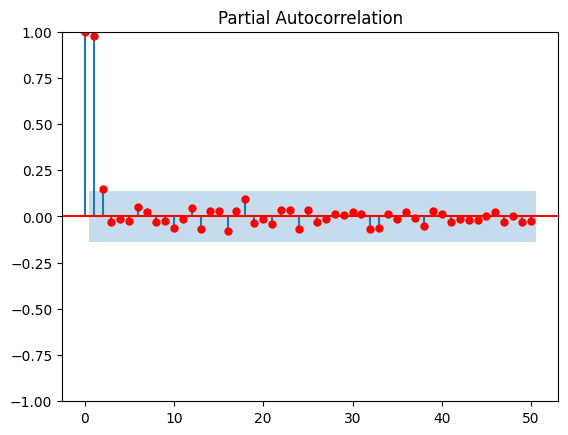

In [64]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df["log"], lags=50, c='r');

In [65]:
p = 2

### 🦎 MA model (choosing "q" "errors" from the past)

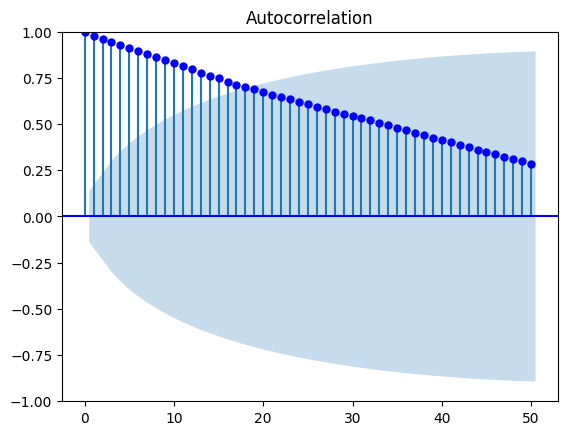

In [66]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df["log"], lags=50, c='b');

In [67]:
q = 15

### ➖ "Integration" / "Differentiation"

In [68]:
non_differenced_data = pd.Series([1, 4, 9, 16, 25, 36])
non_differenced_data

0     1
1     4
2     9
3    16
4    25
5    36
dtype: int64

In [69]:
differenced_data = non_differenced_data.diff(1)
differenced_data

0     NaN
1     3.0
2     5.0
3     7.0
4     9.0
5    11.0
dtype: float64

In [70]:
differenced_differenced_data = differenced_data.diff(1)
differenced_differenced_data

0    NaN
1    NaN
2    2.0
3    2.0
4    2.0
5    2.0
dtype: float64

<Axes: xlabel='date'>

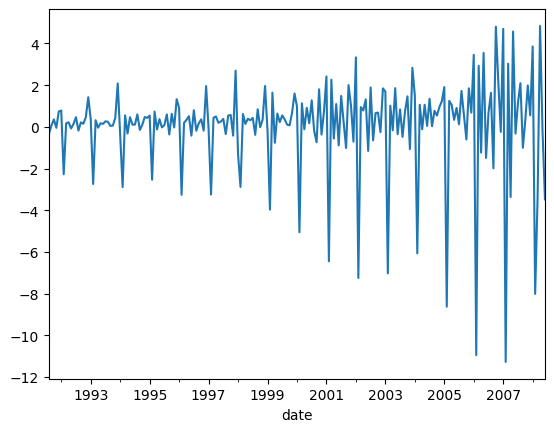

In [71]:
df["value"].diff().dropna().plot()

<Axes: xlabel='date'>

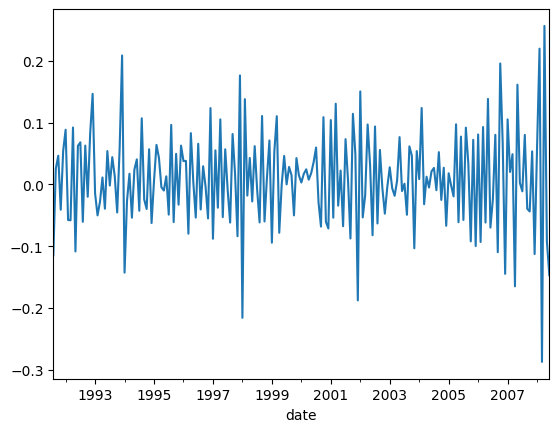

In [72]:
df["log"].diff().dropna().plot()

### 🚀 ARIMA model

In [73]:
!pip freeze | grep statsmodels

statsmodels==0.14.4


In [74]:
train_ratio = 0.60
last_train_index = round(len(df)*train_ratio)

In [75]:
ts_train = df["log"][:last_train_index]
ts_train

date
1991-07-01    1.282057
1991-08-01    1.167492
1991-09-01    1.193013
1991-10-01    1.239482
1991-11-01    1.198554
                ...   
2001-04-01    2.431022
2001-05-01    2.453501
2001-06-01    2.385834
2001-07-01    2.459157
2001-08-01    2.466430
Name: log, Length: 122, dtype: float64

In [76]:
ts_test = df["log"][last_train_index:]
ts_test

date
2001-09-01    2.378958
2001-10-01    2.493323
2001-11-01    2.542676
2001-12-01    2.354999
2002-01-01    2.505592
                ...   
2008-02-01    3.324237
2008-03-01    3.036940
2008-04-01    3.293576
2008-05-01    3.200983
2008-06-01    3.053992
Name: log, Length: 82, dtype: float64

#### 🥋 Train

In [77]:
from statsmodels.tsa.arima.model import ARIMA  #statsmodels 0.12+
# PACF
p=2 
# DIFFERENTIATING
d= 1
# ACF
q= 15

arima = ARIMA(ts_train, order=(p, d, q), trend='t')
arima = arima.fit()

/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/davywai/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [78]:
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                    log   No. Observations:                  122
Model:                ARIMA(2, 1, 15)   Log Likelihood                 201.282
Date:                Tue, 05 Aug 2025   AIC                           -364.564
Time:                        11:27:07   BIC                           -311.444
Sample:                    07-01-1991   HQIC                          -342.990
                         - 08-01-2001                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0101      0.001     12.307      0.000       0.009       0.012
ar.L1         -0.9665      0.691     -1.399      0.162      -2.321       0.388
ar.L2         -0.4303      0.699     -0.615      0.538      -1.801       0.941
ma.L1          0.1099      0.698      0.158      0.875      -1.257       1.477
ma.L2         -0.2368      0.659     -0.359      0.720      -1.529       1.056
ma.L3         -0.3046      0.539     -0.566      0.572      -1.360       0.751
ma.L4         -0.1766      0.151     -1.169      0.242      -0.473       0.119
ma.L5         -0.0815      0.174     -0.468      0.640      -0.423       0.260
ma.L6          0.0334      0.135      0.247      0.805      -0.232       0.299
ma.L7         -0.0347      0.139     -0.250      0.803      -0.307       0.238
ma.L8         -0.0414      0.139     -0.297      0.766      -0.314       0.231
ma.L9          0.0943      0.147      0.642      0.521      -0.194       0.382
ma.L10         0.0203      0.165      0.123      0.902      -0.302       0.343
ma.L11         0.1010      0.137      0.737      0.461      -0.168       0.370
ma.L12         0.4047      0.125      3.247      0.001       0.160       0.649
ma.L13        -0.2014      0.305     -0.660      0.509      -0.799       0.397
ma.L14        -0.3071      0.369     -0.832      0.405      -1.030       0.416
ma.L15        -0.0500      0.366     -0.137      0.891      -0.767       0.667
sigma2         0.0020      0.000      6.802      0.000       0.001       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):                22.85
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               0.54   Skew:                             0.52
Prob(H) (two-sided):                  0.05   Kurtosis:                         4.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#### 🔮 Forecasts

In [79]:
forecasted_results = arima.get_forecast(len(ts_test))
forecasted_results

In [80]:
forecasted_values = forecasted_results.predicted_mean
forecasted_values

2001-09-01    2.431782
2001-10-01    2.515944
2001-11-01    2.453543
2001-12-01    2.444913
2002-01-01    2.517099
                ...   
2008-02-01    3.241912
2008-03-01    3.252056
2008-04-01    3.262199
2008-05-01    3.272343
2008-06-01    3.282487
Freq: MS, Name: predicted_mean, Length: 82, dtype: float64

In [81]:
forecasted_results.conf_int()

,lower log,upper log
2001-09-01,2.344137,2.519427
2001-10-01,2.427403,2.604485
2001-11-01,2.361077,2.546009
2001-12-01,2.350585,2.539242
2002-01-01,2.422646,2.611552
...,...,...
2008-02-01,3.092111,3.391713
2008-03-01,3.101771,3.402341
2008-04-01,3.111432,3.412967
2008-05-01,3.121095,3.423592


In [82]:
lower_case_scenario = forecasted_results.conf_int().values[:,0]
best_case_scenario = forecasted_results.conf_int().values[:,1]

#### 🛠️ Tools

In [83]:
# We define here a "Plot forecast vs. real", which also shows historical training set

def plot_forecast(fc, train, test, upper=None, lower=None):
    is_confidence_int = isinstance(upper, np.ndarray) and isinstance(lower, np.ndarray)
    # Prepare plot series
    fc_series = pd.Series(fc, index=test.index)
    lower_series = pd.Series(upper, index=test.index) if is_confidence_int else None
    upper_series = pd.Series(lower, index=test.index) if is_confidence_int else None

    # Plot
    plt.figure(figsize=(10,4), dpi=100)
    plt.plot(train, label='training', color='black')
    plt.plot(test, label='actual', color='black', ls='--')
    plt.plot(fc_series, label='forecast', color='orange')
    if is_confidence_int:
        plt.fill_between(lower_series.index, lower_series, upper_series, color='k', alpha=.15)
    plt.title('Forecast vs Actuals')
    plt.grid()
    plt.legend(loc='upper left', fontsize=8);

#### 🪄 Plot forecasts

***1- Forecasts of the deseasonalized and delinearized Time Series***

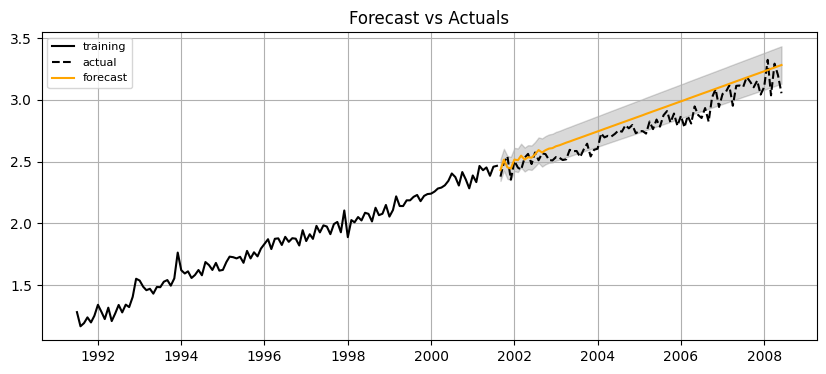

In [84]:
plot_forecast(forecasted_values, 
              ts_train, 
              ts_test, 
              lower_case_scenario, 
              best_case_scenario)

***2- Forecasts of original Time Series***

In [85]:
# TRAIN
ts_train_reconstructed = np.exp(ts_train) * result_mult_log.seasonal[:last_train_index]
# TEST
ts_test_reconstructed = np.exp(ts_test) * result_mult_log.seasonal[last_train_index:]
# FORECASTED
forecasted_values_reconstructed = np.exp(forecasted_values) * result_mult_log.seasonal[last_train_index:]
lower_case_scenario_reconstructed = np.exp(lower_case_scenario) * result_mult_log.seasonal[last_train_index:]
best_case_scenario_reconstructed = np.exp(best_case_scenario) * result_mult_log.seasonal[last_train_index:]

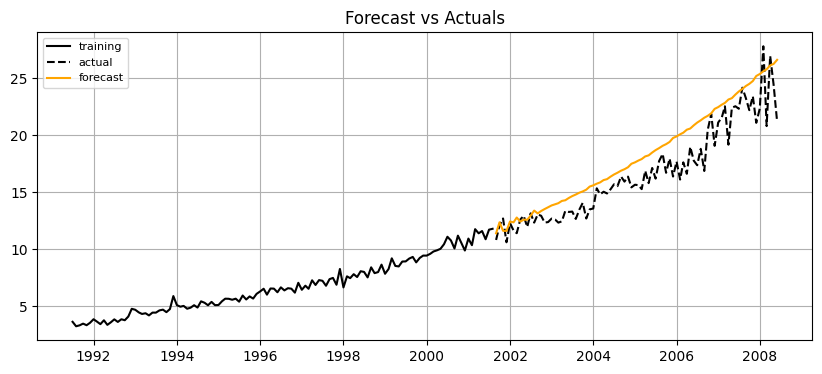

In [86]:
plot_forecast(forecasted_values_reconstructed, 
              ts_train_reconstructed, 
              ts_test_reconstructed, 
              lower_case_scenario_reconstructed, 
              best_case_scenario)